# final practical model and choose the best number of clusters properly


In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

In [4]:
X = pd.read_csv("../data/customer_features_preprocessed.csv")
X.head()

,total_orders,total_spent,average_order_value,recency_days
0,-0.162369,5.898973,6.011875,0.618548
1,9.166697,5.458187,4.192548,-1.481696
2,4.502164,5.171925,4.408634,1.798250
3,-0.162369,5.122689,5.224472,-1.265149
4,-0.162369,5.062756,5.163681,2.109877


In [5]:
X.shape

(96095, 4)

# Elbow method to find the optimal number of clusters (K)


In [8]:
inertias = []
K_values = range(2,9)
for k in K_values:
    model = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )
    model.fit(X)
    inertias.append(model.inertia_)

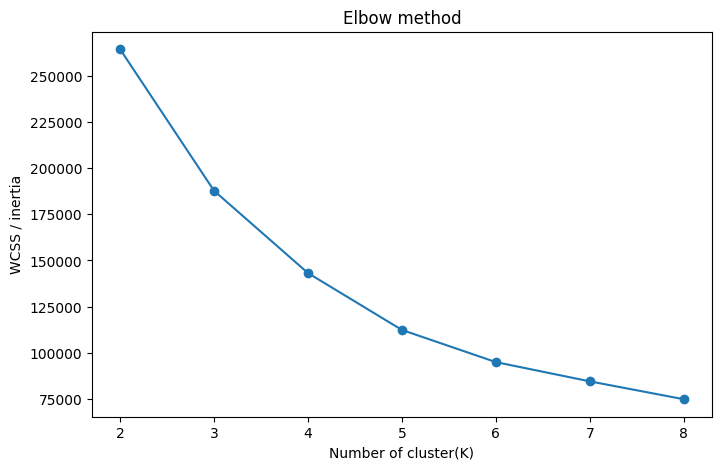

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(
    list(K_values),
    inertias,
    marker="o"
)
plt.xlabel("Number of cluster(K)")
plt.ylabel("WCSS / inertia")
plt.title("Elbow method")
plt.show()

## using silhouette score to confirm our correct choice of the (K) and prevent the argue

In [17]:
silhouette_scores = []
K_values = range(2,9)
for k in K_values:
    model = KMeans(
        n_clusters = k,
        random_state=42,
        n_init=10
    )
    labels = model.fit_predict(X) # clusters
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)
    print(f"K = {k} , silhouette_scores = {score}") 

K = 2 , silhouette_scores = 0.3372599582499624
K = 3 , silhouette_scores = 0.36715296870821285
K = 4 , silhouette_scores = 0.3558757112712207
K = 5 , silhouette_scores = 0.36408529938382844
K = 6 , silhouette_scores = 0.3595553503571459
K = 7 , silhouette_scores = 0.33871667101271546
K = 8 , silhouette_scores = 0.34056666014053993


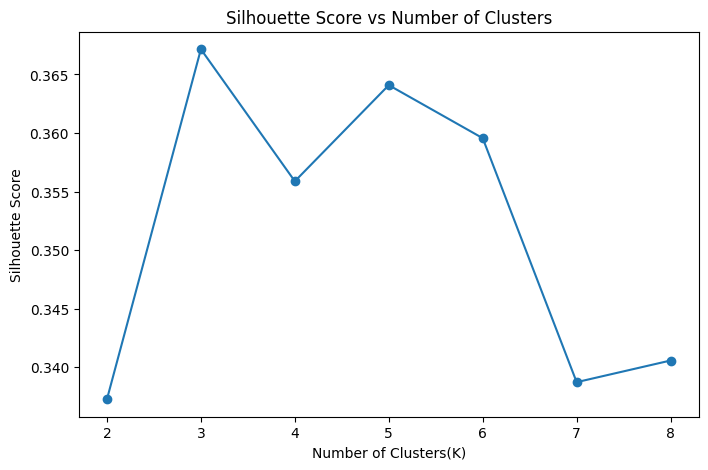

In [18]:
#Plot Silhouette result 
plt.figure(figsize=(8, 5))
plt.plot(
    list(K_values),
    silhouette_scores,
    marker='o'
)
plt.xlabel("Number of Clusters(K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

### The two candidate values for K are 3 and 5

We will train both models and examine the resulting customer profiles to determine which segmentation is more meaningful for the business.

In [20]:
model_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_3 = model_3.fit_predict(X)

In [21]:
model_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_5 = model_5.fit_predict(X)

In [23]:
print("K = 3 clusters sizes:")
print(np.bincount(labels_3))

print("\nK = 5 clusters sizes:")
print(np.bincount(labels_5))

K = 3 clusters sizes:
[ 2997 40987 52111]

K = 5 clusters sizes:
[31474 13187  2997 25533 22904]


In [25]:
customer_data = pd.read_csv("../data/cutomer_features.csv")
customer_data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931


In [26]:
data_k3 = customer_data.copy()
data_k5 = customer_data.copy()

In [27]:
data_k3["cluster"] = labels_3
data_k5["cluster"] = labels_5


In [28]:
data_k3.head(10)

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days,cluster
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106,1
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458,0
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623,0
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505,1
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931,1
5,459bef486812aa25204be022145caa62,1,6922.21,6922.210,2018-07-25 18:10:17,2018-07-25 18:10:17,83.972234,1
6,ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.660,2017-05-24 18:14:34,2017-05-24 18:14:34,510.969259,1
7,4007669dec559734d6f53e029e360987,1,6081.54,6081.540,2017-11-24 11:03:35,2017-11-24 11:03:35,327.268553,1
8,5d0a2980b292d049061542014e8960bf,1,4809.44,4809.440,2018-07-12 12:08:36,2018-07-12 12:08:36,97.223403,1
9,eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.340,2017-04-18 18:50:13,2017-04-18 18:50:13,546.944502,1


In [31]:
profile_k3 = data_k3.groupby('cluster')[
    [
        "total_orders",
        "total_spent",
        "average_order_value",
        "recency_days"
    ]
].mean()
profile_k3

,total_orders,total_spent,average_order_value,recency_days
cluster,,,,
0,2.116116,314.989226,148.500545,268.672901
1,1.000000,281.307838,281.307838,282.824365
2,1.000000,67.833760,67.833760,293.544581


In [32]:
profile_k5 = data_k5.groupby('cluster')[
    [
        "total_orders",
        "total_spent",
        "average_order_value",
        "recency_days"
    ]
].mean()
profile_k5

,total_orders,total_spent,average_order_value,recency_days
cluster,,,,
0,1.000000,149.608375,149.608375,195.194539
1,1.000000,515.316516,515.316516,317.798525
2,2.116116,314.989226,148.500545,268.672901
3,1.000000,50.674578,50.674578,218.053035
4,1.000000,98.966229,98.966229,479.702833


## K=5 was selected as the final number of clusters. Although K=3 achieved the highest Silhouette Score, K=5 achieved a very similar score, was supported by the Elbow Method, and produced more granular and actionable customer segments.

In [34]:
customer_data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931


In [35]:
customer_data["cluster"] = labels_5
customer_data.head()

,customer_unique_id,total_orders,total_spent,average_order_value,first_purchase,last_purchase,recency_days,cluster
0,0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.080,2017-09-29 15:24:52,2017-09-29 15:24:52,383.087106,1
1,46450c74a0d8c5ca9395da1daac6c120,3,9553.02,3184.340,2018-07-24 20:41:01,2018-08-17 20:06:36,60.891458,2
2,da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.815,2017-04-01 15:58:40,2017-04-01 15:58:41,564.063623,2
3,763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.880,2018-07-15 14:49:44,2018-07-15 14:49:44,94.111505,1
4,dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.310,2017-02-12 20:37:36,2017-02-12 20:37:36,611.869931,1


In [36]:
customer_data.to_csv( "../data/customer_segments.csv", index=False)